In [2]:
import pandas as pd

df = pd.read_csv("../data/data.csv")

print(df.head())

  Class          I0     PA500       HFS          DA          Area       A.DA  \
0   car  524.794072  0.187448  0.032114  228.800228   6843.598481  29.910803   
1   car  330.000000  0.226893  0.265290  121.154201   3163.239472  26.109202   
2   car  551.879287  0.232478  0.063530  264.804935  11888.391827  44.894903   
3   car  380.000000  0.240855  0.286234  137.640111   5402.171180  39.248524   
4   car  362.831266  0.200713  0.244346  124.912559   3290.462446  26.342127   

      Max.IP          DR           P  
0  60.204880  220.737212  556.828334  
1  69.717361   99.084964  400.225776  
2  77.793297  253.785300  656.769449  
3  88.758446  105.198568  493.701814  
4  69.389389  103.866552  424.796503  


In [3]:
print("Размер датасета:", df.shape)

print("\nНазвания столбцов:")
print(df.columns.tolist())

print("\nТипы данных:")
print(df.dtypes)

print("\nКоличество пропусков:")
print(df.isnull().sum())

Размер датасета: (106, 10)

Названия столбцов:
['Class', 'I0', 'PA500', 'HFS', 'DA', 'Area', 'A.DA', 'Max.IP', 'DR', 'P']

Типы данных:
Class         str
I0        float64
PA500     float64
HFS       float64
DA        float64
Area      float64
A.DA      float64
Max.IP    float64
DR        float64
P         float64
dtype: object

Количество пропусков:
Class     0
I0        0
PA500     0
HFS       0
DA        0
Area      0
A.DA      0
Max.IP    0
DR        0
P         0
dtype: int64


In [4]:
print("Количество объектов каждого класса:")
print(df["Class"].value_counts())

print("\nКоличество классов:", df["Class"].nunique())

Количество объектов каждого класса:
Class
adi    22
car    21
mas    18
gla    16
fad    15
con    14
Name: count, dtype: int64

Количество классов: 6


In [5]:
df["Target"] = (df["Class"] == "adi").astype(int)

print(df["Target"].value_counts())

Target
0    84
1    22
Name: count, dtype: int64


In [6]:
X = df.drop(columns=["Class", "Target"])
y = df["Target"]

print("X:", X.shape)
print("y:", y.shape)

X: (106, 9)
y: (106,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (84, 9)
Тестовая выборка: (22, 9)


In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Модель обучена")

Модель обучена


In [10]:
y_proba = model.predict_proba(X_test)[:, 1]

print("Первые 10 вероятностей:")
print(y_proba[:10])

Первые 10 вероятностей:
[0.04 0.37 0.   0.98 0.38 0.   0.   0.07 0.96 1.  ]


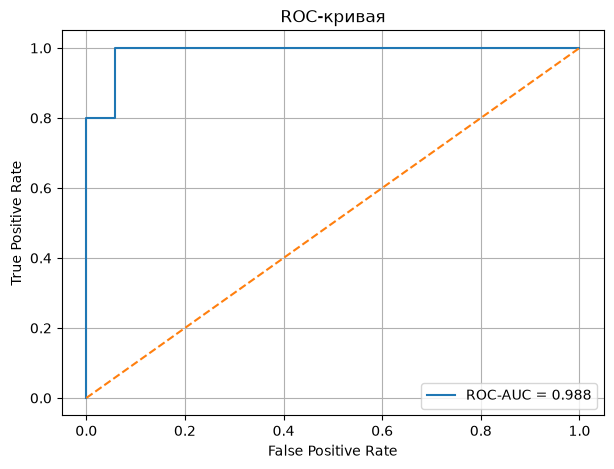

ROC-AUC: 0.988


In [11]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.grid()
plt.show()

print("ROC-AUC:", round(roc_auc, 3))

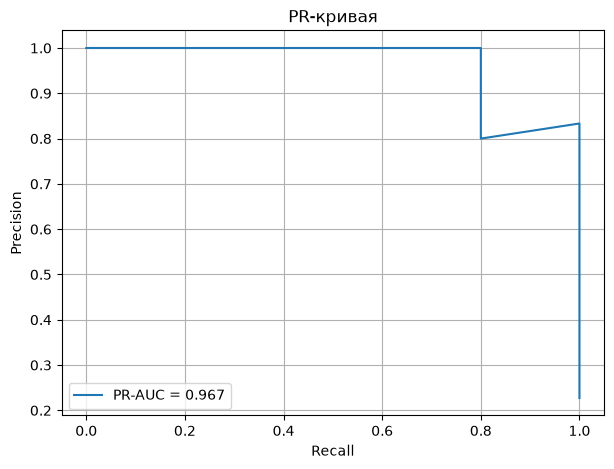

PR-AUC: 0.967


In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR-кривая")
plt.legend()
plt.grid()
plt.show()

print("PR-AUC:", round(pr_auc, 3))

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Порог по умолчанию
threshold_default = 0.5

y_pred_default = (y_proba >= threshold_default).astype(int)

print("Порог:", threshold_default)
print("Accuracy:", round(accuracy_score(y_test, y_pred_default), 3))
print("Precision:", round(precision_score(y_test, y_pred_default), 3))
print("Recall:", round(recall_score(y_test, y_pred_default), 3))
print("F1-score:", round(f1_score(y_test, y_pred_default), 3))

print("\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred_default))

Порог: 0.5
Accuracy: 0.955
Precision: 1.0
Recall: 0.8
F1-score: 0.889

Матрица ошибок:
[[17  0]
 [ 1  4]]


In [14]:
import numpy as np
from sklearn.metrics import f1_score

thresholds_to_check = np.arange(0.1, 0.91, 0.05)

results = []

for threshold in thresholds_to_check:
    y_pred = (y_proba >= threshold).astype(int)
    
    results.append({
        "Порог": round(threshold, 2),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 3),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 3),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 3)
    })

results_df = pd.DataFrame(results)

print(results_df)

    Порог  Precision  Recall     F1
0    0.10      0.714     1.0  0.833
1    0.15      0.833     1.0  0.909
2    0.20      0.833     1.0  0.909
3    0.25      0.833     1.0  0.909
4    0.30      0.833     1.0  0.909
5    0.35      0.833     1.0  0.909
6    0.40      1.000     0.8  0.889
7    0.45      1.000     0.8  0.889
8    0.50      1.000     0.8  0.889
9    0.55      1.000     0.8  0.889
10   0.60      1.000     0.8  0.889
11   0.65      1.000     0.8  0.889
12   0.70      1.000     0.8  0.889
13   0.75      1.000     0.8  0.889
14   0.80      1.000     0.8  0.889
15   0.85      1.000     0.8  0.889
16   0.90      1.000     0.8  0.889


In [15]:
threshold_new = 0.15

y_pred_new = (y_proba >= threshold_new).astype(int)

print("Новый порог:", threshold_new)
print("Accuracy:", round(accuracy_score(y_test, y_pred_new), 3))
print("Precision:", round(precision_score(y_test, y_pred_new), 3))
print("Recall:", round(recall_score(y_test, y_pred_new), 3))
print("F1-score:", round(f1_score(y_test, y_pred_new), 3))

print("\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred_new))

Новый порог: 0.15
Accuracy: 0.955
Precision: 0.833
Recall: 1.0
F1-score: 0.909

Матрица ошибок:
[[16  1]
 [ 0  5]]


In [16]:
print("СРАВНЕНИЕ ПОРОГОВ")
print("=" * 40)

comparison = pd.DataFrame({
    "Метрика": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Порог 0.5": [
        accuracy_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_default)
    ],
    "Порог 0.15": [
        accuracy_score(y_test, y_pred_new),
        precision_score(y_test, y_pred_new),
        recall_score(y_test, y_pred_new),
        f1_score(y_test, y_pred_new)
    ]
})

print(comparison.round(3))

СРАВНЕНИЕ ПОРОГОВ
     Метрика  Порог 0.5  Порог 0.15
0   Accuracy      0.955       0.955
1  Precision      1.000       0.833
2     Recall      0.800       1.000
3   F1-score      0.889       0.909


Вывод: При стандартном пороге 0.5 модель имеет Accuracy = 0.955, Precision = 1.000, Recall = 0.800 и F1-score = 0.889. При подборе порога 0.15 Recall увеличился до 1.000, а F1-score — до 0.909, при этом Accuracy осталась 0.955. Это означает, что новый порог позволяет не пропустить ни одного объекта положительного класса adi, однако приводит к появлению одного ложноположительного результата. Порог 0.15 был выбран на основе максимального значения F1-score среди проверенных порогов.

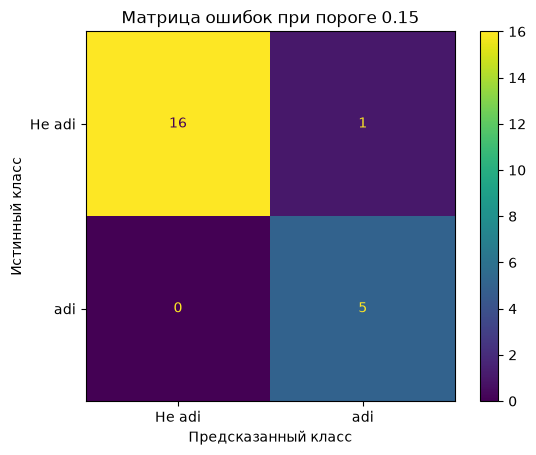

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_new,
    display_labels=["Не adi", "adi"]
)

plt.title("Матрица ошибок при пороге 0.15")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

Итоговый вывод

Для классификации был выбран класс adi как положительный, остальные классы объединены в отрицательный класс. Модель Random Forest выдала вероятности принадлежности к положительному классу с помощью predict_proba.

Качество модели оценивалось с использованием ROC-AUC и PR-AUC. Значение ROC-AUC = 0.988 показывает высокую способность модели различать положительный и отрицательный классы. Значение PR-AUC = 0.967 также показывает высокое качество обнаружения положительного класса.

При стандартном пороге 0.5 были получены Accuracy = 0.955, Precision = 1.000, Recall = 0.800 и F1 = 0.889. При пороге 0.15 Accuracy осталась 0.955, Precision снизилась до 0.833, но Recall увеличился до 1.000, а F1 — до 0.909.

Поэтому был выбран порог 0.15. Он позволил устранить ложноотрицательные результаты на тестовой выборке: FN = 0, хотя количество ложноположительных результатов увеличилось до FP = 1. Таким образом, выбранный порог обеспечивает более высокий Recall и F1 по сравнению со стандартным порогом 0.5.